In [49]:
import asyncio
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import sys
import os

MODULE_FULL_PATH = 'C:/Users/m.hofman/Documents/python_projects/api_stock_from_scratch'
sys.path.insert(1,MODULE_FULL_PATH)

from src.helper_features.excel_features import ExcelOperations
from src.data_handlers import Globals

def write_to_parquet(df, file_name):
    # Change the current working directory
    os.chdir(parquet_path)
    df.to_parquet(path=file_name)

# set type of analysis
Globals.ANALYSIS_TYPE = "full"

excelOperations = ExcelOperations()
folder_path = excelOperations.get_abs_path()


parent_path = folder_path.parent  # Moves one directory down
parquet_path = parent_path / "parquet_files"


# Iterate through the files in the directory
for file_path in folder_path.iterdir():
    # Check if it's a file (not a subdirectory) and not a recovery file
    if file_path.is_file() and file_path.stem[0].isalpha():
        book = openpyxl.load_workbook(file_path)
        substring = str(file_path).split('\\')[-1].replace('.xlsx', '')
        for sheet in book.sheetnames:
            if sheet == 'Sheet1':
                continue
            df = pd.read_excel(file_path, sheet_name=sheet, header=0, index_col=0)
            file_name = sheet + "_" + substring
            # convert the dataframe to a parquet file
            write_to_parquet(df,file_name)

print('process completed')



process completed


In [50]:
pd.read_parquet('rsi_analytics_dataframes_magic_formula') 

,symbol,name,date,open,high,low,close,volume,rsi
0,GNFT,Genfit S.A.,2024-12-17 00:00:00,3.64,3.70,3.63,3.66,5762,28.866501
1,GNFT,Genfit S.A.,2024-12-16 00:00:00,3.83,3.85,3.80,3.80,1435,31.071222
2,GNFT,Genfit S.A.,2024-12-13 00:00:00,3.76,3.82,3.75,3.82,3213,31.396660
3,GNFT,Genfit S.A.,2024-12-12 00:00:00,3.80,3.82,3.73,3.82,2900,31.396660
4,GNFT,Genfit S.A.,2024-12-11 00:00:00,3.88,3.88,3.77,3.83,5525,31.545756
...,...,...,...,...,...,...,...,...,...
415,JIM.L,Jarvis Securities plc,2024-11-26 00:00:00,49.00,50.80,49.00,50.00,10077,52.010703
416,JIM.L,Jarvis Securities plc,2024-11-25 00:00:00,51.10,51.50,49.00,50.00,37310,52.010703
417,JIM.L,Jarvis Securities plc,2024-11-22 00:00:00,49.30,50.50,49.30,50.50,471,53.923192
418,JIM.L,Jarvis Securities plc,2024-11-21 00:00:00,51.40,54.00,49.30,50.50,76277,53.923192


In [51]:
from pyspark.sql import SparkSession

# get key metrics, which are: 
     # marketCap
     # PE ratio
     # revenuePerShare
     # free cash flow per share
     # enterpriseValueOverEBITDA (below 10 is generally seen as a good number)
     #roic
     #roe
 

spark = SparkSession.builder.appName("ReadingParquet").getOrCreate()
dfkeymetrics = spark.read.parquet('key_metrics_analytics_dataframes_magic_formula') 
columns=['symbol', 'name', 'date','marketCap','peRatio', 'earningsYield', 'revenuePerShare', 'freeCashFlowPerShare','enterpriseValueOverEBITDA','roic','roe']
dfkeymetrics = spark.read.parquet('key_metrics_analytics_dataframes_magic_formula').select(columns)


# create a dictionary for redefining column names
# key = old name
# value = new name
dict = {'symbol': 'Share',
        'name': 'Name',
        'date': 'Date',
        'marketCap': 'MarketCap',
        'peRatio' : 'PE',
        'revenuePerShare' : 'RevenuePS',
        'freeCashFlowPerShare' : 'FreeCashFlowPS',
        'earningsYield' : 'EarningsYield',
        'enterpriseValueOverEBITDA': 'EV/Ebitda',
        'roic': 'ROIC',
        'roe' : 'ROE'
       }

dfkeymetrics.printSchema()
dfkeymetrics.show(truncate=False)

root
 |-- symbol: string (nullable = true)
 |-- name: string (nullable = true)
 |-- date: string (nullable = true)
 |-- marketCap: double (nullable = true)
 |-- peRatio: double (nullable = true)
 |-- earningsYield: double (nullable = true)
 |-- revenuePerShare: double (nullable = true)
 |-- freeCashFlowPerShare: double (nullable = true)
 |-- enterpriseValueOverEBITDA: double (nullable = true)
 |-- roic: double (nullable = true)
 |-- roe: double (nullable = true)

+------+-----------+----------+-------------------+-------------------+--------------------+--------------------+--------------------+-------------------------+--------------------+--------------------+
|symbol|name       |date      |marketCap          |peRatio            |earningsYield       |revenuePerShare     |freeCashFlowPerShare|enterpriseValueOverEBITDA|roic                |roe                 |
+------+-----------+----------+-------------------+-------------------+--------------------+--------------------+-------------

In [62]:
# create view which shows the last row of main key metrics for all stocks within selection 
dfkeymetrics.createOrReplaceTempView('key_metrics')
dfkeymetrics_table = spark.sql(
    'SELECT * FROM (SELECT k.symbol, k.name, k.date, k.earningsYield, k.roic, k.roe, ROW_NUMBER() OVER (PARTITION BY k.symbol ORDER BY k.date DESC) as rn from key_metrics AS k) as temp WHERE rn=1'   
)
dfkeymetrics_table.show()
print(type(dfkeymetrics_table))

+--------+--------------------+----------+-------------------+------------------+------------------+---+
|  symbol|                name|      date|      earningsYield|              roic|               roe| rn|
+--------+--------------------+----------+-------------------+------------------+------------------+---+
|ALKOM.PA|Plásticos Compues...|2022-12-31|               null|              null|              null|  1|
|ALNEO.PA|      Alpha MOS S.A.|2024-06-30|  1.387277318954338|0.7198711563270571| 1.229954614220877|  1|
|   BAF.L|British & America...|2024-06-30|  1.091578947368421|0.4776887121087994|0.5347014540579561|  1|
|   CREVW|Carbon Revolution...|2023-06-30|               null|              null|              null|  1|
|  EXO.AS|           Exor N.V.|2024-06-30| 0.3428454464862079|0.1752870755780137|0.1916255900685914|  1|
|    GNFT|         Genfit S.A.|2024-06-30| 0.1635388770699955|0.1954437614251688|0.3113194950854021|  1|
| GNFT.PA|         Genfit S.A.|2024-06-30| 0.1635388770

In [63]:
# Drop duplicate columns of the table created above
pd_table = dfkeymetrics_table.toPandas() 
pd_table


,symbol,name,date,earningsYield,roic,roe,rn
0,ALKOM.PA,"Plásticos Compuestos, S.A.",2022-12-31,NaN,NaN,NaN,1
1,ALNEO.PA,Alpha MOS S.A.,2024-06-30,1.387277,0.719871,1.229955,1
2,BAF.L,British & American Investment Trust PLC,2024-06-30,1.091579,0.477689,0.534701,1
3,CREVW,Carbon Revolution Public Limited Company Warrant,2023-06-30,NaN,NaN,NaN,1
4,EXO.AS,Exor N.V.,2024-06-30,0.342845,0.175287,0.191626,1
5,GNFT,Genfit S.A.,2024-06-30,0.163539,0.195444,0.311319,1
6,GNFT.PA,Genfit S.A.,2024-06-30,0.163539,0.195444,0.311319,1
7,HPAI,Helport AI Limited Ordinary Shares,2023-12-31,NaN,NaN,NaN,1
8,HPAIW,Helport AI Limited Warrants,2023-12-31,NaN,NaN,NaN,1
9,HTCR,"HeartCore Enterprises, Inc.",2024-09-30,0.623519,0.828257,0.891656,1


In [65]:
pd_table

,symbol,name,date,earningsYield,roic,roe,rn
0,ALKOM.PA,"Plásticos Compuestos, S.A.",2022-12-31,NaN,NaN,NaN,1
1,ALNEO.PA,Alpha MOS S.A.,2024-06-30,1.387277,0.719871,1.229955,1
2,BAF.L,British & American Investment Trust PLC,2024-06-30,1.091579,0.477689,0.534701,1
3,CREVW,Carbon Revolution Public Limited Company Warrant,2023-06-30,NaN,NaN,NaN,1
4,EXO.AS,Exor N.V.,2024-06-30,0.342845,0.175287,0.191626,1
5,GNFT,Genfit S.A.,2024-06-30,0.163539,0.195444,0.311319,1
6,GNFT.PA,Genfit S.A.,2024-06-30,0.163539,0.195444,0.311319,1
7,HPAI,Helport AI Limited Ordinary Shares,2023-12-31,NaN,NaN,NaN,1
8,HPAIW,Helport AI Limited Warrants,2023-12-31,NaN,NaN,NaN,1
9,HTCR,"HeartCore Enterprises, Inc.",2024-09-30,0.623519,0.828257,0.891656,1


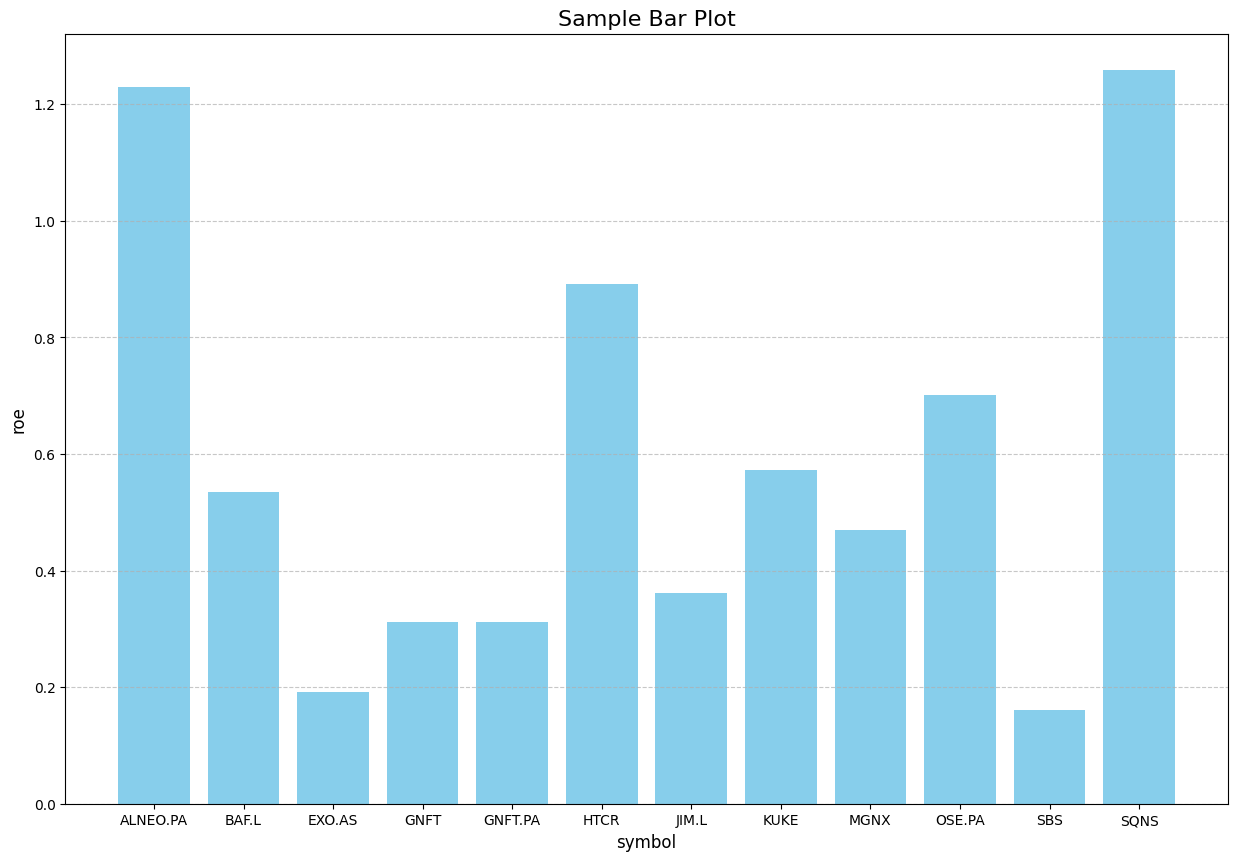

In [66]:

filtered_df = pd_table[pd.notna(pd_table['roe'])]
plt.figure(figsize=(15, 10))
plt.bar(filtered_df['symbol'], filtered_df['roe'], color='skyblue')
plt.title('Sample Bar Plot', fontsize=16)
plt.xlabel('symbol', fontsize=12)
plt.ylabel('roe', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()